# 02 Data Cleaning (Tempo Version)

这个 Notebook 对应重写后的清洗流程，输出目录固定为：

- `D:\Downloads\FYP CHINA\data\tempo\cleaned_cities`
- `D:\Downloads\FYP CHINA\data\tempo\daily_cities`
- `D:\Downloads\FYP CHINA\data\tempo\master_hourly.csv`
- `D:\Downloads\FYP CHINA\data\tempo\master_daily.csv`
- `D:\Downloads\FYP CHINA\data\tempo\clean_summary.csv`



In [ ]:
from pathlib import Path
import importlib.util

script_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\rewrite_data_cleaning.py")
if not script_path.exists():
    raise FileNotFoundError(f"Script not found: {script_path}")

spec = importlib.util.spec_from_file_location("rewrite_data_cleaning", str(script_path))
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

print("Loaded:", script_path)

Loaded: D:\Downloads\FYP CHINA\data\tempo\rewrite_data_cleaning.py


In [1]:
# 结果校验：文件数量、文件大小、预览
from pathlib import Path
import pandas as pd

out_root = Path(r"D:\Downloads\FYP CHINA\data\tempo")
cleaned_dir = out_root / "cleaned_cities"
daily_dir = out_root / "daily_cities"

cleaned_count = len(list(cleaned_dir.glob("*.csv")))
daily_count = len(list(daily_dir.glob("*.csv")))

print("cleaned_cities files:", cleaned_count)
print("daily_cities files:", daily_count)

for f in ["master_hourly.csv", "master_daily.csv", "clean_summary.csv"]:
    p = out_root / f
    print(f"{f}: exists={p.exists()}, size={p.stat().st_size if p.exists() else 0}")

summary_path = out_root / "clean_summary.csv"
if summary_path.exists():
    summary_df = pd.read_csv(summary_path)
    display(summary_df.head(10))

cleaned_cities files: 391
daily_cities files: 391
master_hourly.csv: exists=True, size=396180213
master_daily.csv: exists=True, size=32083525
clean_summary.csv: exists=True, size=12908


,city,rows_hourly,rows_daily,missing_before_AQI,missing_before_PM2.5,missing_before_PM10
0,七台河,50160,2090,609,674,1004
1,三亚,50160,2090,510,517,526
2,三明,50160,2090,511,518,772
3,三沙,206,10,203,203,203
4,三门峡,50160,2090,508,509,513
5,上海,50160,2090,489,489,495
6,上饶,50160,2090,495,496,495
7,东莞,50160,2090,479,480,479
8,东营,50160,2090,492,504,492
9,中卫,50160,2090,526,561,646


In [2]:
# 2) 工作量统计（城市规模、总行数、体积）
from pathlib import Path
import pandas as pd

out_root = Path(r"D:\Downloads\FYP CHINA\data\tempo")
old_root = Path(r"D:\Downloads\FYP CHINA\data")

cleaned_dir = out_root / "cleaned_cities"
daily_dir = out_root / "daily_cities"
raw_dir = old_root / "cities"

master_hourly = out_root / "master_hourly.csv"
master_daily_new = out_root / "master_daily.csv"
master_daily_old = old_root / "master_daily.csv"
summary_path = out_root / "clean_summary.csv"


def file_size_mb(p: Path) -> float:
    return round(p.stat().st_size / (1024 * 1024), 2) if p.exists() else 0.0


def count_rows_fast(csv_path: Path, chunksize: int = 200_000) -> int:
    if not csv_path.exists():
        return 0
    total = 0
    for chunk in pd.read_csv(csv_path, chunksize=chunksize):
        total += len(chunk)
    return int(total)

raw_city_files = len(list(raw_dir.glob("*.csv")))
cleaned_city_files = len(list(cleaned_dir.glob("*.csv")))
daily_city_files = len(list(daily_dir.glob("*.csv")))

rows_master_hourly = count_rows_fast(master_hourly)
rows_master_daily_new = count_rows_fast(master_daily_new)
rows_master_daily_old = count_rows_fast(master_daily_old)

summary_df = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()
city_count = int(summary_df["city"].nunique()) if not summary_df.empty else 0

workload_df = pd.DataFrame([
    {"指标": "原始城市文件数", "数值": raw_city_files},
    {"指标": "清洗后小时文件数", "数值": cleaned_city_files},
    {"指标": "清洗后日级文件数", "数值": daily_city_files},
    {"指标": "覆盖城市数（summary）", "数值": city_count},
    {"指标": "master_hourly 总行数", "数值": rows_master_hourly},
    {"指标": "master_daily(tempo) 总行数", "数值": rows_master_daily_new},
    {"指标": "master_daily(旧版) 总行数", "数值": rows_master_daily_old},
    {"指标": "master_hourly 文件大小(MB)", "数值": file_size_mb(master_hourly)},
    {"指标": "master_daily(tempo) 文件大小(MB)", "数值": file_size_mb(master_daily_new)},
])

display(workload_df)

print("\n输出目录：", out_root)

,指标,数值
0,原始城市文件数,391.00
1,清洗后小时文件数,391.00
2,清洗后日级文件数,391.00
3,覆盖城市数（summary）,391.00
4,master_hourly 总行数,6222452.00
5,master_daily(tempo) 总行数,258219.00
6,master_daily(旧版) 总行数,18066626.00
7,master_hourly 文件大小(MB),377.83
8,master_daily(tempo) 文件大小(MB),30.60



输出目录： D:\Downloads\FYP CHINA\data\tempo


In [4]:
# 3) 新版 tempo 清洗结果概览（不再做旧版对比）
from pathlib import Path
import pandas as pd

new_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\master_daily.csv")
new_df = pd.read_csv(new_path)
new_df["date"] = pd.to_datetime(new_df["date"], errors="coerce")

overview_df = pd.DataFrame([
    {"维度": "城市数", "值": new_df["city"].nunique()},
    {"维度": "日期范围", "值": f"{new_df['date'].min().date()} ~ {new_df['date'].max().date()}"},
    {"维度": "总记录数", "值": f"{len(new_df):,}"},
    {"维度": "每个(city,date)平均记录数", "值": round(new_df.groupby(["city", "date"]).size().mean(), 2)},
    {"维度": "AQI 缺失率", "值": round(new_df["AQI"].isna().mean(), 6)},
    {"维度": "PM2.5 缺失率", "值": round(new_df["PM2.5"].isna().mean(), 6)},
    {"维度": "PM10 缺失率", "值": round(new_df["PM10"].isna().mean(), 6)},
])

display(overview_df)

# 展示新版主表样例（方便答辩截图）
display(new_df.head(10))

print("Tempo 清洗主表路径:", new_path)

,维度,值
0,城市数,138
1,日期范围,2020-01-01 ~ 2025-09-20
2,总记录数,"258,219"
3,"每个(city,date)平均记录数",1.0
4,AQI 缺失率,0.0
5,PM2.5 缺失率,0.0
6,PM10 缺失率,0.0


,city,date,AQI,PM2.5,PM10,SO2,NO2,CO,O3
0,七台河,2020-01-01,63.625000,41.875000,64.458333,15.541667,38.291667,0.737500,40.000000
1,七台河,2020-01-02,41.166667,25.791667,36.291667,11.958333,50.583333,0.775000,43.000000
2,七台河,2020-01-03,75.000000,54.750000,73.000000,22.166667,62.958333,1.075000,39.875000
3,七台河,2020-01-04,135.208333,103.250000,124.833333,23.458333,76.958333,1.300000,30.666667
4,七台河,2020-01-05,90.416667,67.041667,84.291667,18.625000,69.291667,1.133333,37.083333
5,七台河,2020-01-06,120.125000,92.375000,116.500000,18.375000,73.166667,1.700000,32.520833
6,七台河,2020-01-07,71.166667,51.875000,61.916667,14.083333,38.625000,0.975000,45.875000
7,七台河,2020-01-08,83.500000,61.791667,75.125000,19.208333,54.708333,0.950000,29.291667
8,七台河,2020-01-09,127.875000,97.541667,115.666667,20.583333,66.125000,1.150000,27.083333
9,七台河,2020-01-10,98.333333,73.458333,90.416667,14.458333,67.833333,1.133333,30.041667


Tempo 清洗主表路径: D:\Downloads\FYP CHINA\data\tempo\master_daily.csv


,污染物,清洗前缺失总量
0,PM10,302966
1,PM2.5,267371
2,AQI,243735


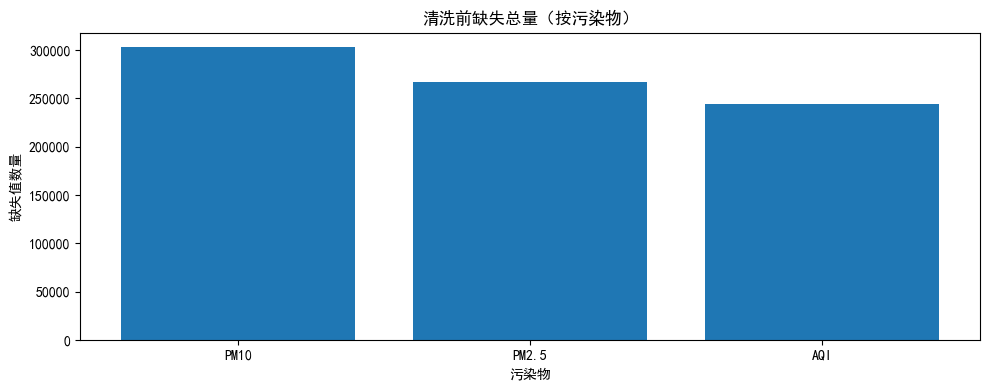


上图是清洗前的缺失规模，清洗后版本在主表中已完成插值与填补（用于建模与可视化）。


In [6]:
# 4) 缺失修复规模展示（给老师看工作量）
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # Use a font that supports Chinese
plt.rcParams['axes.unicode_minus'] = False   # Correctly display minus signs

summary_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\clean_summary.csv")
summary_df = pd.read_csv(summary_path)

missing_cols = [c for c in summary_df.columns if c.startswith("missing_before_")]
missing_sum = summary_df[missing_cols].sum().sort_values(ascending=False)
missing_show = missing_sum.rename(lambda x: x.replace("missing_before_", ""))

display(pd.DataFrame({"污染物": missing_show.index, "清洗前缺失总量": missing_show.values}))

plt.figure(figsize=(10, 4))
plt.bar(missing_show.index, missing_show.values)
plt.title("清洗前缺失总量（按污染物）")
plt.xlabel("污染物")
plt.ylabel("缺失值数量")
plt.tight_layout()
plt.show()

print("\n上图是清洗前的缺失规模，清洗后版本在主表中已完成插值与填补（用于建模与可视化）。")

,污染物,清洗前缺失量,清洗后缺失量,减少量,改善率(%)
0,AQI,243735,0,243735,100.0
1,PM2.5,267371,0,267371,100.0
2,PM10,302966,0,302966,100.0


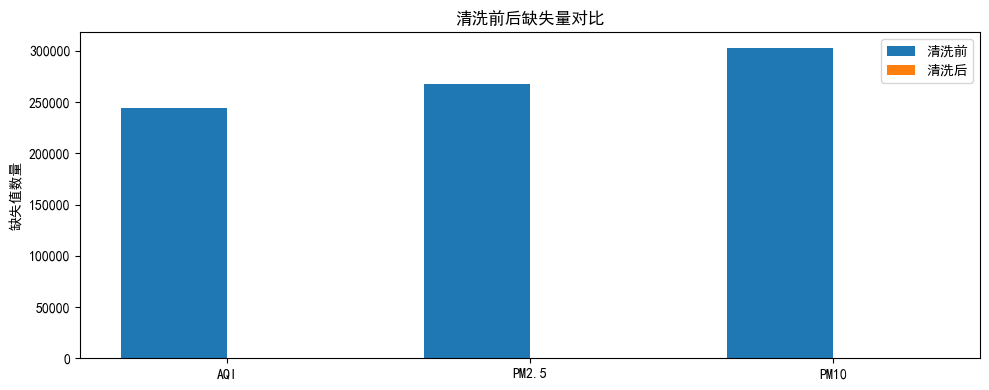


说明：清洗后缺失量基于 tempo 主表 master_daily.csv 统计。


In [7]:
# 5) 清洗前后对比（表格 + 可视化）
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

summary_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\clean_summary.csv")
master_daily_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\master_daily.csv")

summary_df = pd.read_csv(summary_path)
master_daily_df = pd.read_csv(master_daily_path)

pollutants = ["AQI", "PM2.5", "PM10"]
before = {p: int(summary_df[f"missing_before_{p}"].sum()) for p in pollutants}
after = {p: int(master_daily_df[p].isna().sum()) for p in pollutants}

compare_df = pd.DataFrame({
    "污染物": pollutants,
    "清洗前缺失量": [before[p] for p in pollutants],
    "清洗后缺失量": [after[p] for p in pollutants],
})
compare_df["减少量"] = compare_df["清洗前缺失量"] - compare_df["清洗后缺失量"]
compare_df["改善率(%)"] = np.where(
    compare_df["清洗前缺失量"] > 0,
    compare_df["减少量"] / compare_df["清洗前缺失量"] * 100,
    0,
).round(2)

display(compare_df)

x = np.arange(len(compare_df))
width = 0.35

plt.figure(figsize=(10, 4))
plt.bar(x - width / 2, compare_df["清洗前缺失量"], width, label="清洗前")
plt.bar(x + width / 2, compare_df["清洗后缺失量"], width, label="清洗后")
plt.xticks(x, compare_df["污染物"])
plt.ylabel("缺失值数量")
plt.title("清洗前后缺失量对比")
plt.legend()
plt.tight_layout()
plt.show()

print("\n说明：清洗后缺失量基于 tempo 主表 master_daily.csv 统计。")

,指标,清洗前,清洗后,变化
0,数据记录数,1.757957e+07,258219.0,-1.732136e+07
1,字段总数(3项污染物),5.273872e+07,774657.0,-5.196406e+07
2,缺失字段数,8.140720e+05,0.0,-8.140720e+05
3,字段缺失率,1.543600e+00,0.0,-1.543600e+00


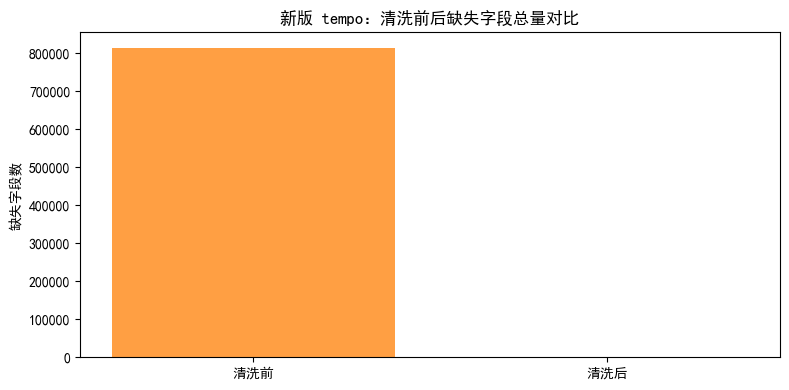

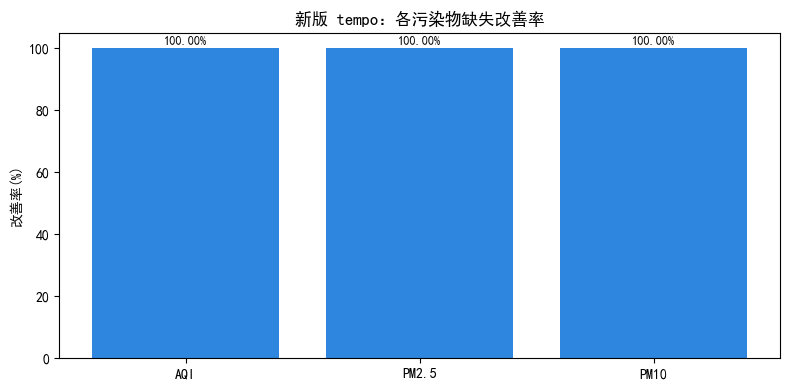

说明：整体对比基于 clean_summary（清洗前）与 master_daily（清洗后）统计。


In [8]:
# 6) 新版 tempo：更完整的清洗前后对比（整体指标）
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

summary_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\clean_summary.csv")
master_daily_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\master_daily.csv")

summary_df = pd.read_csv(summary_path)
master_daily_df = pd.read_csv(master_daily_path)

pollutants = ["AQI", "PM2.5", "PM10"]

# 清洗前（按 summary 汇总）
before_total_rows = int(summary_df["rows_hourly"].sum())
before_total_fields = before_total_rows * len(pollutants)
before_missing = int(sum(summary_df[f"missing_before_{p}"].sum() for p in pollutants))
before_missing_rate = before_missing / before_total_fields if before_total_fields else 0

# 清洗后（按 master_daily 实际结果统计）
after_total_rows = int(len(master_daily_df))
after_total_fields = after_total_rows * len(pollutants)
after_missing = int(sum(master_daily_df[p].isna().sum() for p in pollutants))
after_missing_rate = after_missing / after_total_fields if after_total_fields else 0

kpi_df = pd.DataFrame([
    {"指标": "数据记录数", "清洗前": before_total_rows, "清洗后": after_total_rows, "变化": after_total_rows - before_total_rows},
    {"指标": "字段总数(3项污染物)", "清洗前": before_total_fields, "清洗后": after_total_fields, "变化": after_total_fields - before_total_fields},
    {"指标": "缺失字段数", "清洗前": before_missing, "清洗后": after_missing, "变化": after_missing - before_missing},
    {"指标": "字段缺失率", "清洗前": round(before_missing_rate * 100, 4), "清洗后": round(after_missing_rate * 100, 4), "变化": round((after_missing_rate - before_missing_rate) * 100, 4)},
])

display(kpi_df)

# 缺失字段数对比图
plt.figure(figsize=(8, 4))
plt.bar(["清洗前", "清洗后"], [before_missing, after_missing], color=["#ff9f43", "#10ac84"])
plt.ylabel("缺失字段数")
plt.title("新版 tempo：清洗前后缺失字段总量对比")
plt.tight_layout()
plt.show()

# 各污染物改善率图
before_by_pollutant = [int(summary_df[f"missing_before_{p}"].sum()) for p in pollutants]
after_by_pollutant = [int(master_daily_df[p].isna().sum()) for p in pollutants]
reduce_rate = [
    (b - a) / b * 100 if b else 0
    for b, a in zip(before_by_pollutant, after_by_pollutant)
]

plt.figure(figsize=(8, 4))
plt.bar(pollutants, reduce_rate, color="#2e86de")
plt.ylim(0, 105)
plt.ylabel("改善率(%)")
plt.title("新版 tempo：各污染物缺失改善率")
for i, v in enumerate(reduce_rate):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("说明：整体对比基于 clean_summary（清洗前）与 master_daily（清洗后）统计。")

,city,before_missing_total,after_missing_total,reduced_total,improve_rate(%)
257,瓦房店,34002,0,34002,100.0
315,赣江新区,16370,0,16370,100.0
44,兰州新区,14259,0,14259,100.0
305,西咸新区,14192,0,14192,100.0
366,雄安新区,14151,0,14151,100.0
77,和田地区,13263,0,13263,100.0
298,蓬莱,10973,0,10973,100.0
220,海东地区,9697,0,9697,100.0
90,塔城地区,8151,0,8151,100.0
329,那曲地区,8146,0,8146,100.0


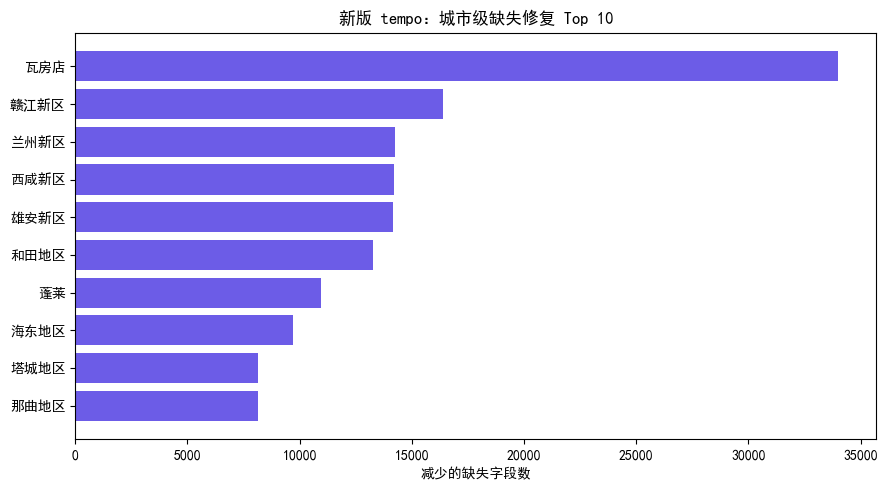

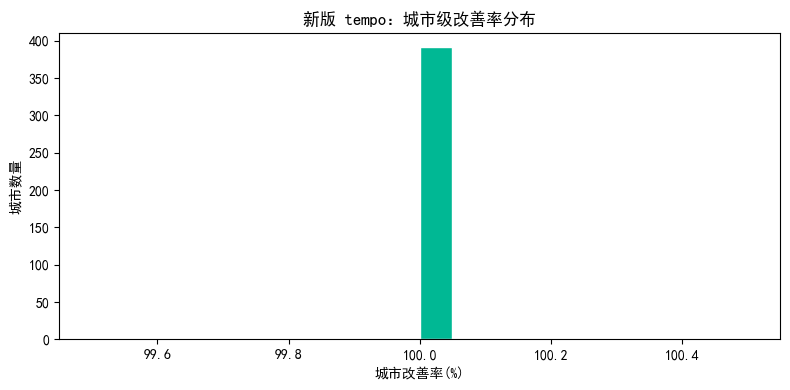

补充说明：可结合 Top10 城市表，解释哪些城市清洗收益最大。


In [9]:
# 7) 新版 tempo：城市级对比（Top 改善城市 + 分布）
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

summary_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\clean_summary.csv")
master_daily_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\master_daily.csv")

summary_df = pd.read_csv(summary_path)
master_daily_df = pd.read_csv(master_daily_path)

pollutants = ["AQI", "PM2.5", "PM10"]

# 每城市清洗前缺失总量
before_city = summary_df[["city"] + [f"missing_before_{p}" for p in pollutants]].copy()
before_city["before_missing_total"] = before_city[[f"missing_before_{p}" for p in pollutants]].sum(axis=1)
before_city = before_city[["city", "before_missing_total"]]

# 每城市清洗后缺失总量（按 master_daily 实际统计）
after_city = (
    master_daily_df.groupby("city")[pollutants]
    .apply(lambda g: g.isna().sum().sum())
    .reset_index(name="after_missing_total")
)

city_compare_df = before_city.merge(after_city, on="city", how="left")
city_compare_df["after_missing_total"] = city_compare_df["after_missing_total"].fillna(0).astype(int)
city_compare_df["reduced_total"] = city_compare_df["before_missing_total"] - city_compare_df["after_missing_total"]
city_compare_df["improve_rate(%)"] = (
    city_compare_df["reduced_total"] / city_compare_df["before_missing_total"].replace(0, pd.NA) * 100
).fillna(0).round(2)

# Top 10 改善城市
top10_df = city_compare_df.sort_values("reduced_total", ascending=False).head(10)
display(top10_df)

plt.figure(figsize=(9, 5))
plt.barh(top10_df["city"], top10_df["reduced_total"], color="#6c5ce7")
plt.gca().invert_yaxis()
plt.xlabel("减少的缺失字段数")
plt.title("新版 tempo：城市级缺失修复 Top 10")
plt.tight_layout()
plt.show()

# 城市级改善率分布
plt.figure(figsize=(8, 4))
plt.hist(city_compare_df["improve_rate(%)"], bins=20, color="#00b894", edgecolor="white")
plt.xlabel("城市改善率(%)")
plt.ylabel("城市数量")
plt.title("新版 tempo：城市级改善率分布")
plt.tight_layout()
plt.show()

print("补充说明：可结合 Top10 城市表，解释哪些城市清洗收益最大。")

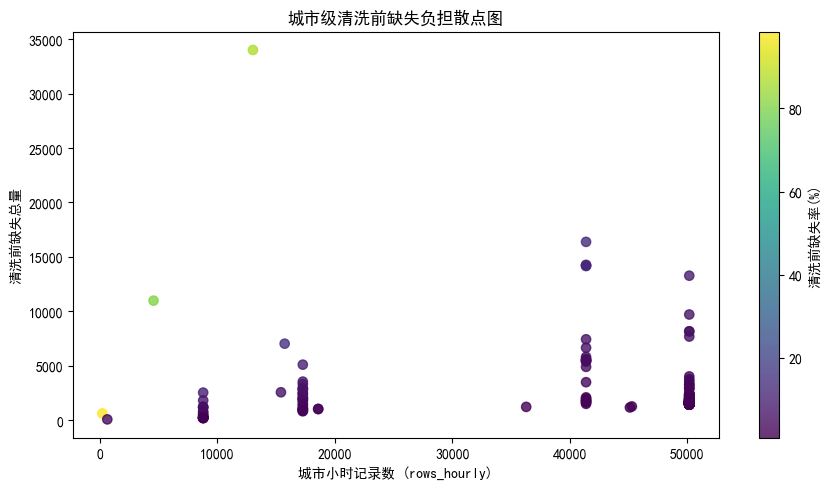

,city,rows_hourly,before_missing_total,before_missing_rate(%)
257,瓦房店,13021,34002,87.04
315,赣江新区,41375,16370,13.19
44,兰州新区,41375,14259,11.49
305,西咸新区,41375,14192,11.43
366,雄安新区,41375,14151,11.40
77,和田地区,50160,13263,8.81
298,蓬莱,4559,10973,80.23
220,海东地区,50160,9697,6.44
90,塔城地区,50160,8151,5.42
329,那曲地区,50160,8146,5.41


说明：散点图用于定位清洗重点城市，高点代表清洗前缺失负担更重。


In [11]:
# 8) 散点图：城市样本规模 vs 清洗前缺失量（定位清洗重点）
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

summary_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\clean_summary.csv")
summary_df = pd.read_csv(summary_path)

pollutants = ["AQI", "PM2.5", "PM10"]
missing_cols = [f"missing_before_{p}" for p in pollutants]

city_scatter_df = summary_df[["city", "rows_hourly"] + missing_cols].copy()
city_scatter_df["before_missing_total"] = city_scatter_df[missing_cols].sum(axis=1)
city_scatter_df["before_missing_rate(%)"] = (
    city_scatter_df["before_missing_total"] / (city_scatter_df["rows_hourly"] * len(pollutants)) * 100
).round(2)

# 散点图：X=城市小时记录数，Y=清洗前缺失总量，颜色=缺失率
plt.figure(figsize=(9, 5))
scatter = plt.scatter(
    city_scatter_df["rows_hourly"],
    city_scatter_df["before_missing_total"],
    c=city_scatter_df["before_missing_rate(%)"],
    cmap="viridis",
    s=45,
    alpha=0.8,
)
plt.colorbar(scatter, label="清洗前缺失率(%)")
plt.xlabel("城市小时记录数 (rows_hourly)")
plt.ylabel("清洗前缺失总量")
plt.title("城市级清洗前缺失负担散点图")
plt.tight_layout()
plt.show()

# 展示缺失最重的城市，辅助解释散点中的高点
top_missing_city = city_scatter_df.sort_values("before_missing_total", ascending=False).head(10)
display(top_missing_city[["city", "rows_hourly", "before_missing_total", "before_missing_rate(%)"]])

print("说明：散点图用于定位清洗重点城市，高点代表清洗前缺失负担更重。")

In [ ]:
# 9) 散点图：城市清洗前缺失量 vs 清洗后缺失量（检验修复效果）
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

summary_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\clean_summary.csv")
master_daily_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\master_daily.csv")

summary_df = pd.read_csv(summary_path)
master_daily_df = pd.read_csv(master_daily_path)

pollutants = ["AQI", "PM2.5", "PM10"]

before_city = summary_df[["city"] + [f"missing_before_{p}" for p in pollutants]].copy()
before_city["before_missing_total"] = before_city[[f"missing_before_{p}" for p in pollutants]].sum(axis=1)
before_city = before_city[["city", "before_missing_total"]]

after_city = (
    master_daily_df.groupby("city")[pollutants]
    .apply(lambda g: int(g.isna().sum().sum()))
    .reset_index(name="after_missing_total")
)

city_compare = before_city.merge(after_city, on="city", how="left")
city_compare["after_missing_total"] = city_compare["after_missing_total"].fillna(0)

plt.figure(figsize=(8.5, 5))
plt.scatter(
    city_compare["before_missing_total"],
    city_compare["after_missing_total"],
    s=42,
    alpha=0.75,
    color="#3867d6",
)

max_x = max(1, city_compare["before_missing_total"].max())
plt.plot([0, max_x], [0, 0], "--", color="gray", linewidth=1)

plt.xlabel("清洗前缺失总量（按城市）")
plt.ylabel("清洗后缺失总量（按城市）")
plt.title("新版 tempo：城市级清洗前后缺失量散点图")
plt.tight_layout()
plt.show()

print("说明：点越接近 y=0，表示该城市清洗后缺失越少。")

In [ ]:
# 10) 散点图：清洗前缺失率 vs 修复量（城市级效率视角）
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

summary_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\clean_summary.csv")
master_daily_path = Path(r"D:\Downloads\FYP CHINA\data\tempo\master_daily.csv")

summary_df = pd.read_csv(summary_path)
master_daily_df = pd.read_csv(master_daily_path)

pollutants = ["AQI", "PM2.5", "PM10"]

before_city = summary_df[["city", "rows_hourly"] + [f"missing_before_{p}" for p in pollutants]].copy()
before_city["before_missing_total"] = before_city[[f"missing_before_{p}" for p in pollutants]].sum(axis=1)
before_city["before_missing_rate(%)"] = (
    before_city["before_missing_total"] / (before_city["rows_hourly"] * len(pollutants)) * 100
)
before_city = before_city[["city", "before_missing_total", "before_missing_rate(%)"]]

after_city = (
    master_daily_df.groupby("city")[pollutants]
    .apply(lambda g: int(g.isna().sum().sum()))
    .reset_index(name="after_missing_total")
)

city_compare = before_city.merge(after_city, on="city", how="left")
city_compare["after_missing_total"] = city_compare["after_missing_total"].fillna(0)
city_compare["repaired_total"] = city_compare["before_missing_total"] - city_compare["after_missing_total"]

plt.figure(figsize=(9, 5))
sc = plt.scatter(
    city_compare["before_missing_rate(%)"],
    city_compare["repaired_total"],
    c=city_compare["before_missing_total"],
    cmap="plasma",
    s=50,
    alpha=0.8,
)
plt.colorbar(sc, label="清洗前缺失总量")
plt.xlabel("清洗前缺失率(%)")
plt.ylabel("修复量（减少的缺失字段数）")
plt.title("新版 tempo：城市级缺失率与修复量散点图")
plt.tight_layout()
plt.show()

# 右上角城市（高缺失率 + 高修复量）可作为答辩重点案例
focus_df = city_compare.sort_values(["before_missing_rate(%)", "repaired_total"], ascending=False).head(10)
display(focus_df[["city", "before_missing_rate(%)", "before_missing_total", "repaired_total"]])

print("说明：该图用于识别高缺失率且修复收益高的重点城市。")